# Fashion MNIST Classifier using CNN (Convolutional Neural Networks)

In [10]:
import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import pandas as pd

torch.manual_seed(42)

In [11]:
train_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

print(f"Length of train data: {len(train_data)}")
print(f"Length of test data: {len(test_data)}")

Length of train data: 60000
Length of test data: 10000


In [12]:
class_names = train_data.classes
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [13]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Length of train_dataloader: {len(train_dataloader)}, No. of images per batch: {BATCH_SIZE}")
print(f"Length of test_dataloader: {len(test_dataloader)}, No. of images per batch: {BATCH_SIZE}")

Length of train_dataloader: 1875, No. of images per batch: 32
Length of test_dataloader: 313, No. of images per batch: 32


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

Device : cuda


In [15]:
class MNISTModel1(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(
                in_channels=1, out_channels=32,
                kernel_size=3, stride=1, padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=32, out_channels=64,
                kernel_size=3, stride=1, padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(in_features=64*14*14, out_features=128),
            nn.ReLU(),
            
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_block(x)

        return self.classifier(x)

model_1 = MNISTModel1().to(device)
model_1

MNISTModel1(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12544, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [16]:
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model_1.parameters(),
    lr=0.0005
)

train_accuracy = MulticlassAccuracy(
    num_classes=len(class_names),
    average="weighted"
).to(device)

train_precision = MulticlassPrecision(
    num_classes=len(class_names),
    average="weighted"
).to(device)

train_recall = MulticlassRecall(
    num_classes=len(class_names),
    average="weighted"
).to(device)

train_f1 = MulticlassF1Score(
    num_classes=len(class_names),
    average="weighted"
).to(device)


test_accuracy = MulticlassAccuracy(
    num_classes=len(class_names),
    average="weighted"
).to(device)

test_precision = MulticlassPrecision(
    num_classes=len(class_names),
    average="weighted"
).to(device)

test_recall = MulticlassRecall(
    num_classes=len(class_names),
    average="weighted"
).to(device)

test_f1 = MulticlassF1Score(
    num_classes=len(class_names),
    average="weighted"
).to(device)

In [17]:
epochs = 20

train_loss_history, test_loss_history = [], []
train_acc_history, test_acc_history = [], []
train_precision_history, test_precision_history = [], []
train_recall_history, test_recall_history = [], []
train_f1_history, test_f1_history = [], []

for epoch in range(epochs):
    print(f"Epoch {epoch}: \n----------")

    train_loss = 0

    model_1.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model_1(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        train_accuracy.update(y_pred, y)
        train_precision.update(y_pred, y)
        train_recall.update(y_pred, y)
        train_f1.update(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)

    train_acc = train_accuracy.compute()
    train_prec = train_precision.compute()
    train_rec = train_recall.compute()
    train_f1_score = train_f1.compute()

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc.item())
    train_precision_history.append(train_prec.item())
    train_recall_history.append(train_rec.item())
    train_f1_history.append(train_f1_score.item())

    train_accuracy.reset()
    train_precision.reset()
    train_recall.reset()
    train_f1.reset()

    test_loss = 0
    model_1.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            test_pred = model_1(X_test)
            test_loss += loss_fn(test_pred, y_test).item()

            test_accuracy.update(test_pred, y_test)
            test_precision.update(test_pred, y_test)
            test_recall.update(test_pred, y_test)
            test_f1.update(test_pred, y_test)

        test_loss /= len(test_dataloader)

        test_acc = test_accuracy.compute()
        test_prec = test_precision.compute()
        test_rec = test_recall.compute()
        test_f1_score = test_f1.compute()

        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc.item())
        test_precision_history.append(test_prec.item())
        test_recall_history.append(test_rec.item())
        test_f1_history.append(test_f1_score.item())

        # Reset testing metrics
        test_accuracy.reset()
        test_precision.reset()
        test_recall.reset()
        test_f1.reset()

    print(
        f"\nTrain Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train Precision: {train_prec:.4f} | "
        f"Train Recall: {train_rec:.4f} | "
        f"Train F1: {train_f1_score:.4f}"
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"Test Precision: {test_prec:.4f} | "
        f"Test Recall: {test_rec:.4f} | "
        f"Test F1: {test_f1_score:.4f}\n"
    )


Epoch 0: 
----------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples

Train Loss: 0.4047 | Train Acc: 0.8547 | Train Precision: 0.8535 | Train Recall: 0.8547 | Train F1: 0.8538
Test Loss: 0.3323 | Test Acc: 0.8811 | Test Precision: 0.8850 | Test Recall: 0.8811 | Test F1: 0.8788

Epoch 1: 
----------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples

Train Loss: 0.2528 | Train Acc: 0.9086 | Train Precision: 0.9082 | Train Recall: 0.9086 | Train F1: 0.9083
Test Loss: 0.2666 | Test Acc: 0.9036 | Test Precision: 0.9040 | Test Recall: 0.9036 | Test F1: 0.9033

Epoch 2: 
----------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples

Train Loss: 0.2047 | Train Acc: 0.9256 | Train

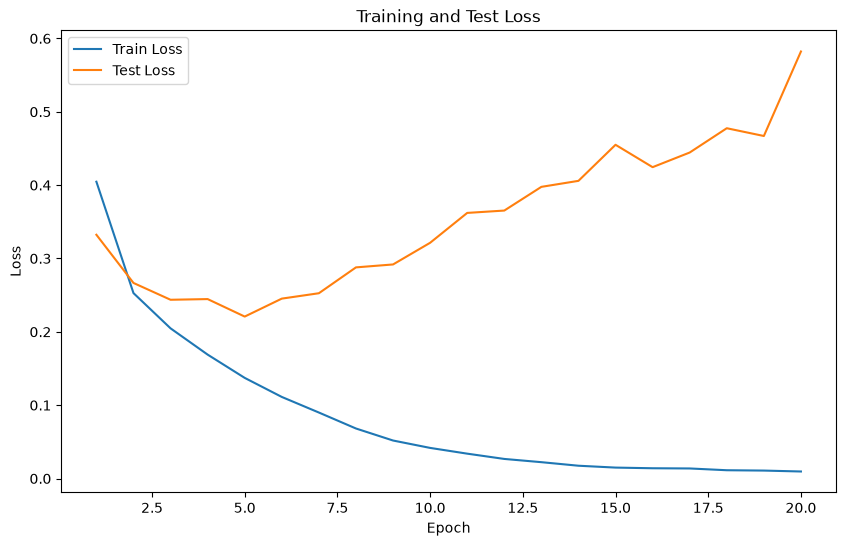

In [18]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_loss_history,
    label="Train Loss"
)

plt.plot(
    epochs_range,
    test_loss_history,
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()

plt.show()

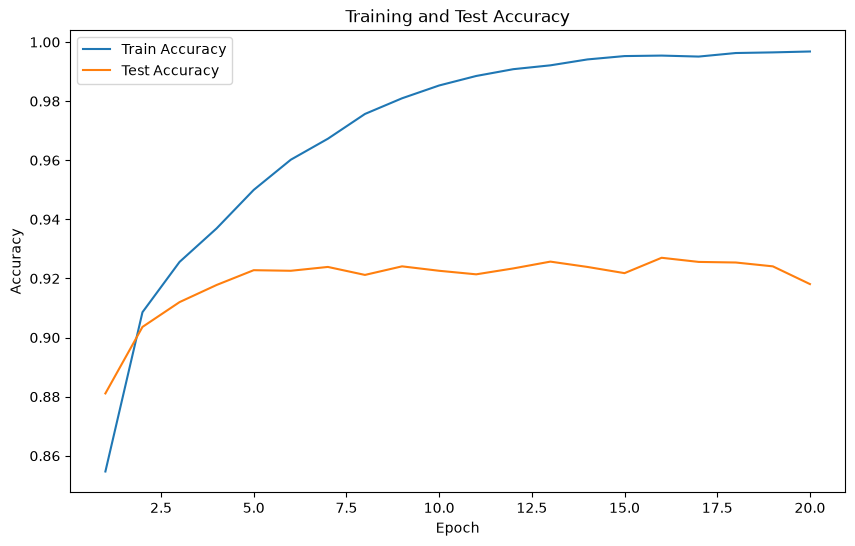

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_acc_history,
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    test_acc_history,
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()

plt.show()

In [20]:
model_1.eval()

all_images = []
all_preds = []
all_labels = []

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)

        logits = model_1(X)
        preds = logits.argmax(dim=1)

        all_images.append(X.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

all_images = torch.cat(all_images)
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

correct_indices = torch.where(all_preds == all_labels)[0]
wrong_indices = torch.where(all_preds != all_labels)[0]

print("Correct:", len(correct_indices))
print("Wrong:", len(wrong_indices))

Correct: 9181
Wrong: 819


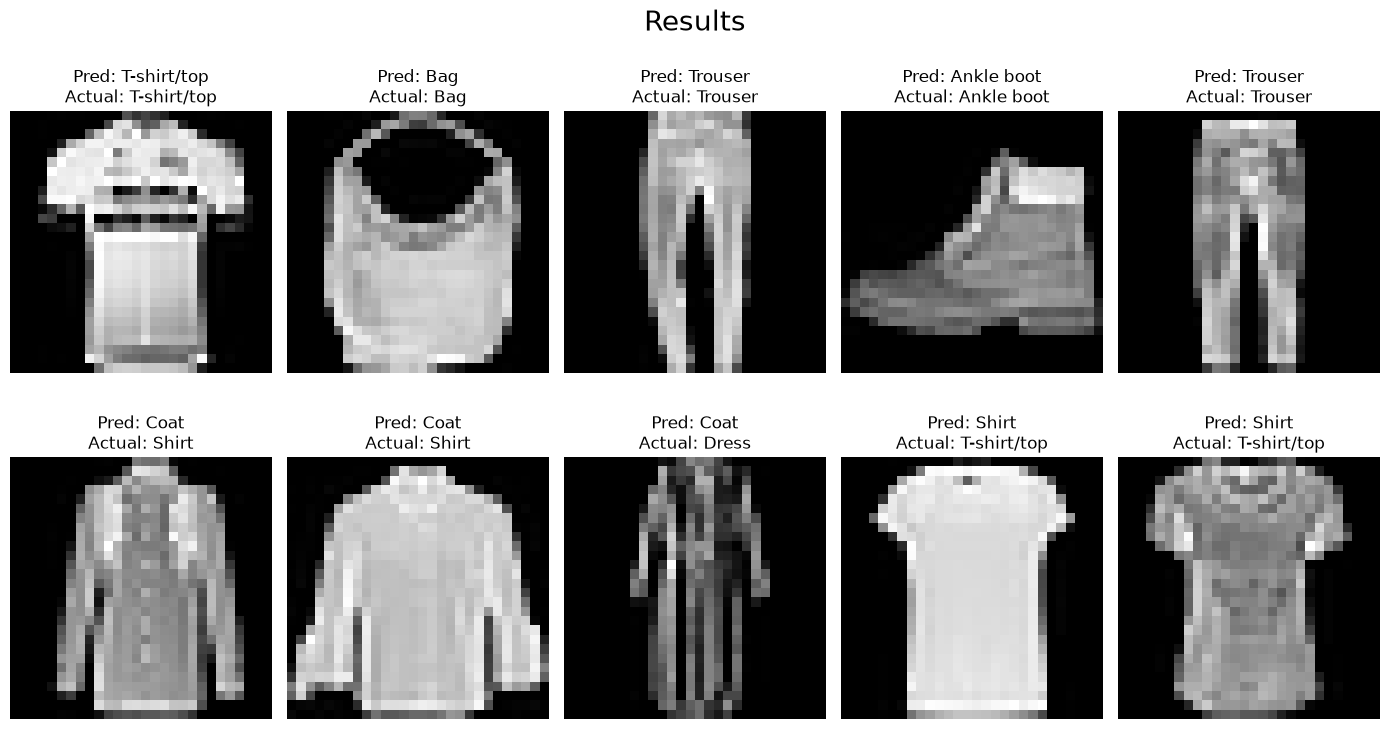

In [21]:
import random

num_correct = 5
num_wrong = 5

selected_correct = random.sample(correct_indices.tolist(), num_correct)
selected_wrong = random.sample(wrong_indices.tolist(), num_wrong)

selected_indices = selected_correct + selected_wrong



plt.figure(figsize=(14, 8))

for i, idx in enumerate(selected_indices):

    image = all_images[idx].squeeze()

    predicted_label = class_names[all_preds[idx]]
    actual_label = class_names[all_labels[idx]]

    plt.subplot(2, 5, i + 1)

    plt.imshow(image, cmap="gray")
    plt.axis("off")

    if all_preds[idx] == all_labels[idx]:
        title = f"Pred: {predicted_label}\nActual: {actual_label}"
    else:
        title = f"Pred: {predicted_label}\nActual: {actual_label}"

    plt.title(title, fontsize=12)

plt.suptitle("Results", fontsize=20)
plt.tight_layout()
plt.show()

In [23]:
torch.save(model_1.state_dict(), r"../models/cnn_baseline.pt")
print(f"CNN Baseline Model saved to models/cnn_baseline.pt")

CNN Baseline Model saved to models/cnn_baseline.pt
